# 🏎️ F1 Pit Stop Strategy - Strategy Generator

**Author:** Ionut Vladeanu  
**Course:** IAPD - Machine Learning Project  
**Date:** January 2026

---

## 📋 Notebook Overview

This notebook uses the **calibrated ML model** to generate race strategy predictions.

### Key Features:
- **Calibrated probabilities**: 0.5 threshold works correctly!
- **Simulation mode**: Test custom race scenarios
- **Realistic constraints**: Minimum stint length, track-specific rules

### User Configurable Parameters:
- Track selection (affects pit loss time, lap count)
- Starting grid position
- Starting tire compound
- Safety car scenarios

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import pickle
import json
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported")

✓ Libraries imported


In [2]:
# Load calibrated classifier + PolicyEngine
import pickle
from src.policy.decision_engine import PolicyEngine

# Load the calibrated pit probability classifier (same as before)
model_path = Path.cwd() / "models" / "pit_classifier.pkl"

with open(model_path, "rb") as f:
    model_data = pickle.load(f)

clf = model_data["model"]
scaler = model_data["scaler"]
FEATURE_COLS = model_data["feature_cols"]

policy = PolicyEngine()

print(f"✓ Calibrated pit classifier loaded from: {model_path}")
print(f"  Feature columns: {len(FEATURE_COLS)}")

✓ Calibrated pit classifier loaded from: /Users/vionut/Master ACS SD/IAPD/F1_Model/models/pit_classifier.pkl
  Feature columns: 16


---
## 2. Track Profiles (Circuit Database)

In [3]:
# Track profiles with typical characteristics
TRACK_PROFILES = {
    'Abu Dhabi': {'laps': 58, 'pit_loss_s': 22.0, 'avg_lap_time_s': 88.0, 'deg_rate': 0.05, 'min_pit_lap': 15},
    'Bahrain': {'laps': 57, 'pit_loss_s': 21.0, 'avg_lap_time_s': 92.0, 'deg_rate': 0.06, 'min_pit_lap': 14},
    'Saudi Arabia': {'laps': 50, 'pit_loss_s': 20.0, 'avg_lap_time_s': 89.0, 'deg_rate': 0.04, 'min_pit_lap': 12},
    'Australia': {'laps': 58, 'pit_loss_s': 23.0, 'avg_lap_time_s': 80.0, 'deg_rate': 0.05, 'min_pit_lap': 15},
    'Japan': {'laps': 53, 'pit_loss_s': 22.0, 'avg_lap_time_s': 93.0, 'deg_rate': 0.05, 'min_pit_lap': 13},
    'China': {'laps': 56, 'pit_loss_s': 22.0, 'avg_lap_time_s': 96.0, 'deg_rate': 0.06, 'min_pit_lap': 14},
    'Miami': {'laps': 57, 'pit_loss_s': 21.0, 'avg_lap_time_s': 90.0, 'deg_rate': 0.05, 'min_pit_lap': 14},
    'Monaco': {'laps': 78, 'pit_loss_s': 24.0, 'avg_lap_time_s': 74.0, 'deg_rate': 0.02, 'min_pit_lap': 25},
    'Canada': {'laps': 70, 'pit_loss_s': 21.0, 'avg_lap_time_s': 75.0, 'deg_rate': 0.04, 'min_pit_lap': 18},
    'Spain': {'laps': 66, 'pit_loss_s': 22.0, 'avg_lap_time_s': 78.0, 'deg_rate': 0.07, 'min_pit_lap': 16},
    'Austria': {'laps': 71, 'pit_loss_s': 20.0, 'avg_lap_time_s': 66.0, 'deg_rate': 0.05, 'min_pit_lap': 18},
    'Great Britain': {'laps': 52, 'pit_loss_s': 21.0, 'avg_lap_time_s': 89.0, 'deg_rate': 0.06, 'min_pit_lap': 13},
    'Hungary': {'laps': 70, 'pit_loss_s': 23.0, 'avg_lap_time_s': 78.0, 'deg_rate': 0.04, 'min_pit_lap': 18},
    'Belgium': {'laps': 44, 'pit_loss_s': 22.0, 'avg_lap_time_s': 105.0, 'deg_rate': 0.05, 'min_pit_lap': 11},
    'Netherlands': {'laps': 72, 'pit_loss_s': 19.0, 'avg_lap_time_s': 72.0, 'deg_rate': 0.06, 'min_pit_lap': 18},
    'Italy (Monza)': {'laps': 53, 'pit_loss_s': 24.0, 'avg_lap_time_s': 82.0, 'deg_rate': 0.03, 'min_pit_lap': 13},
    'Singapore': {'laps': 62, 'pit_loss_s': 28.0, 'avg_lap_time_s': 98.0, 'deg_rate': 0.04, 'min_pit_lap': 16},
    'United States (COTA)': {'laps': 56, 'pit_loss_s': 21.0, 'avg_lap_time_s': 96.0, 'deg_rate': 0.06, 'min_pit_lap': 14},
    'Mexico': {'laps': 71, 'pit_loss_s': 22.0, 'avg_lap_time_s': 78.0, 'deg_rate': 0.05, 'min_pit_lap': 18},
    'Brazil': {'laps': 71, 'pit_loss_s': 21.0, 'avg_lap_time_s': 72.0, 'deg_rate': 0.05, 'min_pit_lap': 18},
    'Las Vegas': {'laps': 50, 'pit_loss_s': 20.0, 'avg_lap_time_s': 95.0, 'deg_rate': 0.04, 'min_pit_lap': 12},
    'Qatar': {'laps': 57, 'pit_loss_s': 22.0, 'avg_lap_time_s': 85.0, 'deg_rate': 0.08, 'min_pit_lap': 14},
}

print("📋 Available Tracks:")
for track, info in TRACK_PROFILES.items():
    print(f"   • {track:25} ({info['laps']} laps)")

📋 Available Tracks:
   • Abu Dhabi                 (58 laps)
   • Bahrain                   (57 laps)
   • Saudi Arabia              (50 laps)
   • Australia                 (58 laps)
   • Japan                     (53 laps)
   • China                     (56 laps)
   • Miami                     (57 laps)
   • Monaco                    (78 laps)
   • Canada                    (70 laps)
   • Spain                     (66 laps)
   • Austria                   (71 laps)
   • Great Britain             (52 laps)
   • Hungary                   (70 laps)
   • Belgium                   (44 laps)
   • Netherlands               (72 laps)
   • Italy (Monza)             (53 laps)
   • Singapore                 (62 laps)
   • United States (COTA)      (56 laps)
   • Mexico                    (71 laps)
   • Brazil                    (71 laps)
   • Las Vegas                 (50 laps)
   • Qatar                     (57 laps)


---
## 3. 🎮 SIMULATION MODE - Configure Your Race

**Modify the parameters below to create your hypothetical race scenario:**

In [4]:
# ============================================
# 🎮 USER CONFIGURATION - MODIFY THESE!
# ============================================

# Track selection
TRACK = "Monaco"  # Choose from TRACK_PROFILES above

# Starting conditions
GRID_POSITION = 3 # 1-20
START_COMPOUND = "HARD"  # SOFT, MEDIUM, HARD

# Race simulation parameters
DRIVER_NAME = "Ionut Vladeanu"  # Just for output labels

# Safety Car simulation (optional)
SAFETY_CAR_LAPS = [31, 32, 33, 34, 35]   # e.g., [15, 16, 17] to simulate SC on laps 15-17

# ============================================
# STRATEGY CONSTRAINTS
# ============================================
# With the calibrated model, probabilities are generally in the 0.00–0.30 range.
# A threshold around 0.15–0.20 is more realistic than 0.8 for triggering pit calls.
PROBABILITY_THRESHOLD = 0.18  # Decision threshold for pit recommendation
MIN_STINT_LAPS = 10           # Absolute minimum laps before first pit (unless SC)

# Compound-specific pit offsets: medium/hard can safely go longer than soft
COMPOUND_PIT_OFFSET = {
    'SOFT': 0,
    'MEDIUM': 7,   # medium: ~7 laps later than soft
    'HARD': 12,    # hard: ~12 laps later than soft
}

# ============================================

track_info = TRACK_PROFILES[TRACK]
compound_key = START_COMPOUND.upper()
compound_offset = COMPOUND_PIT_OFFSET.get(compound_key, 0)
# Track-specific minimum + compound-dependent offset
COMPOUND_MIN_PIT_LAP = max(MIN_STINT_LAPS, track_info['min_pit_lap'] + compound_offset)

print(f"\n📊 Race Configuration:")
print(f"   Track: {TRACK}")
print(f"   Total laps: {track_info['laps']}")
print(f"   Pit loss: {track_info['pit_loss_s']}s")
print(f"   Degradation rate: {track_info['deg_rate']} s/lap")
print(f"\n   Grid position: P{GRID_POSITION}")
print(f"   Starting compound: {START_COMPOUND}")
print(f"   Safety car laps: {SAFETY_CAR_LAPS if SAFETY_CAR_LAPS else 'None'}")
print(f"   Compound min pit lap: {COMPOUND_MIN_PIT_LAP} (incl. compound offset)")
print(f"\n   Probability threshold: {PROBABILITY_THRESHOLD} (calibrated model)")


📊 Race Configuration:
   Track: Monaco
   Total laps: 78
   Pit loss: 24.0s
   Degradation rate: 0.02 s/lap

   Grid position: P3
   Starting compound: HARD
   Safety car laps: [31, 32, 33, 34, 35]
   Compound min pit lap: 37 (incl. compound offset)

   Probability threshold: 0.18 (calibrated model)


---
## 4. Generate Simulated Race Data

In [5]:
def simulate_race_laps(track_info, grid_pos, start_compound, sc_laps):
    """Generate synthetic lap data for a simulated race."""
    
    total_laps = track_info['laps']
    laps = []
    
    # Initialize state
    current_compound = start_compound
    tyre_age = 1
    position = grid_pos
    
    for lap in range(1, total_laps + 1):
        # Calculate features
        lap_progress = lap / total_laps
        remaining = total_laps - lap
        
        # Degradation increases with tire age
        base_deg = track_info['deg_rate']
        compound_mult = {'SOFT': 1.5, 'MEDIUM': 1.0, 'HARD': 0.6}.get(current_compound, 1.0)
        degradation = base_deg * compound_mult * (1 + tyre_age / 30)

        # Risk grows faster on softer tyres, slower on harder ones
        risk_base = {'SOFT': 18, 'MEDIUM': 25, 'HARD': 32}.get(current_compound, 25)
        risk_score = min(1.0, tyre_age / risk_base)
        
        # Safety car check
        is_sc = lap in sc_laps
        
        # Simple position changes (random walk with mean reversion)
        np.random.seed(42 + lap)  # Reproducible randomness
        if lap > 1 and not is_sc:
            pos_change = np.random.choice([-1, 0, 0, 0, 1])
            position = max(1, min(20, position + pos_change))
        
        # Build feature row
        lap_data = {
            'lap_number': lap,
            'lap_progress_pct': lap_progress,
            'remaining_laps': remaining,
            'tyre_age_laps': tyre_age,
            'tyre_age_pct': tyre_age / total_laps,
            'position': position,
            'degradation_s_per_lap': degradation,
            'safety_car_flag': 1 if is_sc else 0,
            'virtual_sc_flag': 0,
            'in_battle_flag': 1 if position > 3 and position < 15 else 0,
            'risk_score': risk_score,
            # Compound dummies
            'compound_HARD': 1 if current_compound == 'HARD' else 0,
            'compound_INTERMEDIATE': 0,
            'compound_MEDIUM': 1 if current_compound == 'MEDIUM' else 0,
            'compound_SOFT': 1 if current_compound == 'SOFT' else 0,
            'compound_WET': 0,
            # Extra info
            '_compound': current_compound,
        }
        
        laps.append(lap_data)
        tyre_age += 1
    
    return pd.DataFrame(laps)

# Generate simulated race
sim_df = simulate_race_laps(track_info, GRID_POSITION, START_COMPOUND, SAFETY_CAR_LAPS)
print(f"✓ Generated {len(sim_df)} simulated laps")

✓ Generated 78 simulated laps


---
## 5. Run ML Model Predictions

In [6]:
# Prepare features for calibrated classifier using the same feature set as training
from src.features.feature_engineering import get_feature_columns

# Build feature frame with all model feature columns (fill missing with 0)
feature_cols = FEATURE_COLS
X_sim = pd.DataFrame({f: sim_df[f] if f in sim_df.columns else 0 for f in feature_cols})
X_sim = X_sim.fillna(0)

# Scale and predict pit probabilities (next 1 lap)
X_scaled = scaler.transform(X_sim)
pit_probs_1 = clf.predict_proba(X_scaled)[:, 1]

# Add predictions to dataframe
sim_df['pit_probability'] = pit_probs_1

print(f"\n✓ Predictions generated!")
print(f"   Probability range: {pit_probs_1.min():.3f} - {pit_probs_1.max():.3f}")
print(f"   Peak probability: {pit_probs_1.max():.3f} at Lap {pit_probs_1.argmax() + 1}")


✓ Predictions generated!
   Probability range: 0.000 - 0.006
   Peak probability: 0.006 at Lap 27


---
## 6. Visualize Strategy Predictions

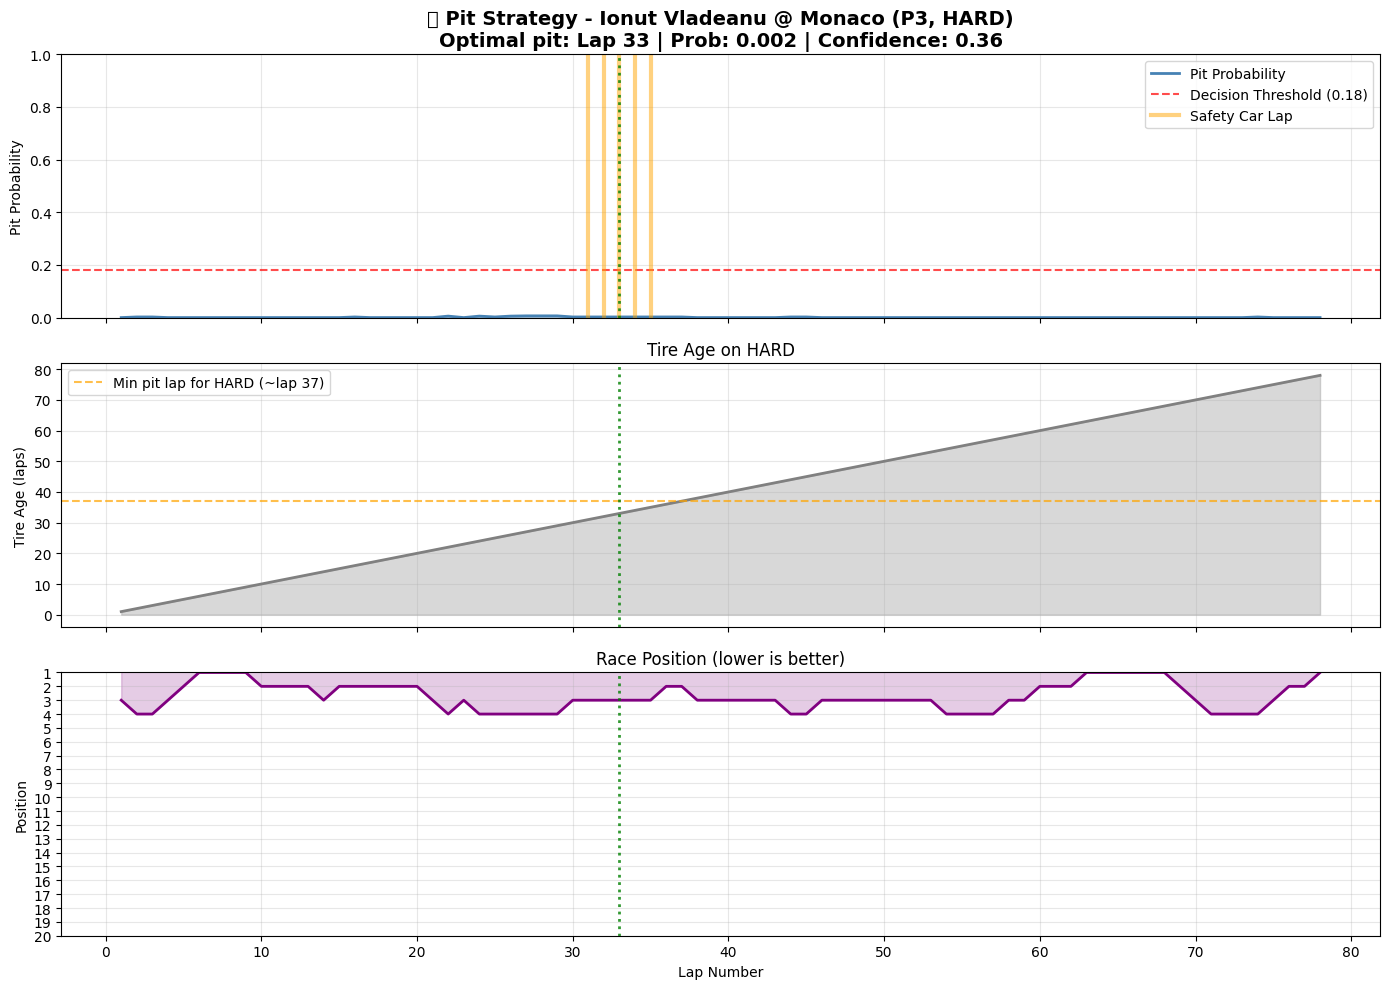

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# --- Compute key strategy points for annotations ---
# Use the SAME logic as JSON strategy: respect **compound-aware** min pit lap
valid_df = sim_df[sim_df['lap_number'] >= COMPOUND_MIN_PIT_LAP].copy()

# 1) If a Safety Car lap is available after the minimum stint, prefer that as a "cheap" pit stop
#    (we allow pitting a bit earlier than the compound window because SC makes it cheaper)
valid_sc_laps = [lap for lap in SAFETY_CAR_LAPS if lap >= MIN_STINT_LAPS]

if valid_sc_laps:
    # Use the SAME rule as in the JSON strategy: pick the middle SC lap as the optimal stop
    sorted_sc = sorted(valid_sc_laps)
    recommended = valid_df[valid_df['lap_number'].isin(sorted_sc)]
    optimal_lap = int(sorted_sc[len(sorted_sc) // 2])
else:
    # 2) Otherwise, use model-based high-probability window
    high_prob = valid_df[valid_df['pit_probability'] > PROBABILITY_THRESHOLD]
    if len(high_prob) > 0:
        recommended = high_prob.copy()
        # Middle of the high-probability window
        optimal_lap = int(recommended['lap_number'].iloc[len(recommended) // 2])
    else:
        # 3) Fallback: peak probability AFTER COMPOUND_MIN_PIT_LAP
        peak_idx = valid_df['pit_probability'].idxmax()
        optimal_lap = int(valid_df.loc[peak_idx, 'lap_number'])
        recommended = valid_df[valid_df['lap_number'] == optimal_lap]

peak_prob = float(sim_df['pit_probability'].max())
opt_prob = float(sim_df.loc[sim_df['lap_number'] == optimal_lap, 'pit_probability'].iloc[0])
opt_conf = opt_prob / max(peak_prob, 1e-6)

# Plot 1: Pit Probability
ax1 = axes[0]
ax1.fill_between(sim_df['lap_number'], sim_df['pit_probability'], alpha=0.3, color='steelblue')
ax1.plot(sim_df['lap_number'], sim_df['pit_probability'], color='steelblue', linewidth=2, label='Pit Probability')
ax1.axhline(y=PROBABILITY_THRESHOLD, color='red', linestyle='--', alpha=0.7, 
            label=f'Decision Threshold ({PROBABILITY_THRESHOLD})')

# # Mark minimum stint zone (compound-aware)
# ax1.axvspan(0, COMPOUND_MIN_PIT_LAP, alpha=0.08, color='gray', label='Invalid pit window (stint too short)')

# Mark recommended pit laps
if len(recommended) > 0:
    ax1.scatter(recommended['lap_number'], recommended['pit_probability'], 
                color='green', s=100, zorder=5, label='Recommended Pit', marker='^')

# Mark safety car laps
for i, sc_lap in enumerate(SAFETY_CAR_LAPS):
    label = 'Safety Car Lap' if i == 0 else None
    ax1.axvline(x=sc_lap, color='orange', linestyle='-', alpha=0.5, linewidth=3, label=label)

# Vertical line at optimal pit lap across all plots (added later)

ax1.set_ylabel('Pit Probability')
ax1.set_title(
    f'🏎️ Pit Strategy - {DRIVER_NAME} @ {TRACK} (P{GRID_POSITION}, {START_COMPOUND.upper()})\n'
    f'Optimal pit: Lap {optimal_lap} | Prob: {opt_prob:.3f} | Confidence: {opt_conf:.2f}',
    fontsize=14,
    fontweight='bold'
)
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# Plot 2: Tire Age
ax2 = axes[1]
compound_color = {'SOFT': 'red', 'MEDIUM': 'gold', 'HARD': 'gray'}.get(START_COMPOUND.upper(), 'black')
ax2.plot(sim_df['lap_number'], sim_df['tyre_age_laps'], color=compound_color, linewidth=2)
ax2.fill_between(sim_df['lap_number'], sim_df['tyre_age_laps'], alpha=0.3, color=compound_color)
ax2.axhline(y=COMPOUND_MIN_PIT_LAP, color='orange', linestyle='--', alpha=0.7,
            label=f"Min pit lap for {START_COMPOUND.upper()} (~lap {COMPOUND_MIN_PIT_LAP})")
ax2.set_ylabel('Tire Age (laps)')
ax2.set_title(f'Tire Age on {START_COMPOUND.upper()}', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')

# Plot 3: Position
ax3 = axes[2]
ax3.plot(sim_df['lap_number'], sim_df['position'], color='purple', linewidth=2)
ax3.fill_between(sim_df['lap_number'], sim_df['position'], alpha=0.2, color='purple')
ax3.set_xlabel('Lap Number')
ax3.set_ylabel('Position')
ax3.set_title('Race Position (lower is better)', fontsize=12)
ax3.invert_yaxis()
ax3.set_ylim(20, 1)
ax3.set_yticks(range(1, 21))
ax3.grid(True, alpha=0.3)

# Draw optimal pit lap as a vertical line across all subplots
for ax in axes:
    ax.axvline(x=optimal_lap, color='green', linestyle=':', alpha=0.8, linewidth=2)

plt.tight_layout()
plt.show()

---
## 7. Strategy Recommendation

In [8]:
def find_optimal_pit_window(df, threshold, min_lap):
    """Find optimal pit window from calibrated probabilities."""
    # Filter to valid range
    valid_df = df[df['lap_number'] >= min_lap].copy()

    high_prob_laps = valid_df[valid_df['pit_probability'] > threshold]['lap_number'].tolist()
    if high_prob_laps:
        return high_prob_laps

    # Fallback: peak probability lap after min_lap
    if len(valid_df) > 0:
        peak_idx = valid_df['pit_probability'].idxmax()
        peak_lap = int(valid_df.loc[peak_idx, 'lap_number'])
        return [peak_lap]

    return [min_lap]


# Priority 1: Safety Car - pit during SC if it occurs after minimum stint
# This saves ~14 seconds compared to normal pit stop!
valid_sc_laps = [
    lap for lap in SAFETY_CAR_LAPS
    if lap >= MIN_STINT_LAPS  # Only respect absolute minimum, not compound offset
]


if valid_sc_laps:
    candidate_laps = sorted(valid_sc_laps)
else:
    # 2) Fall back to model-based window from calibrated probabilities
    candidate_laps = find_optimal_pit_window(sim_df, PROBABILITY_THRESHOLD, COMPOUND_MIN_PIT_LAP)

# Choose the middle lap of the candidate window as the "optimal" stop
optimal_pit_lap = int(candidate_laps[len(candidate_laps) // 2]) if candidate_laps else COMPOUND_MIN_PIT_LAP

# Get probability at optimal lap
optimal_prob = float(sim_df.loc[sim_df['lap_number'] == optimal_pit_lap, 'pit_probability'].iloc[0])

# Generate a simple 1-stop strategy from start to finish
first_stint_end = optimal_pit_lap
second_stint_start = optimal_pit_lap + 1

strategy = {
    'race_config': {
        'track': TRACK,
        'total_laps': track_info['laps'],
        'driver': DRIVER_NAME,
        'grid_position': GRID_POSITION,
        'starting_compound': START_COMPOUND,
        'safety_car_laps': SAFETY_CAR_LAPS
    },
    'ml_prediction': {
        'optimal_pit_lap': optimal_pit_lap,
        'pit_probability_calibrated': round(optimal_prob, 3),
        'pit_confidence': round(optimal_prob / max(sim_df['pit_probability'].max(), 1e-6), 3) if sim_df['pit_probability'].max() > 0 else 0.0,
        'recommended_window': candidate_laps[:5] if len(candidate_laps) > 5 else candidate_laps,
        'peak_probability': round(sim_df['pit_probability'].max(), 3),
        'threshold_used': PROBABILITY_THRESHOLD
    },
    'strategy': {
        'number_of_stops': 1,
        'first_stint': {
            'compound': START_COMPOUND,
            'from_lap': 1,
            'to_lap': int(first_stint_end),
            'laps': int(first_stint_end),
        },
        'second_stint': {
            'compound': 'HARD' if START_COMPOUND.upper() in ['SOFT', 'MEDIUM'] else 'MEDIUM',
            'from_lap': int(second_stint_start),
            'to_lap': track_info['laps'],
            'laps': int(track_info['laps'] - first_stint_end),
        },
    },
}

print("\n" + "="*60)
print("📋 STRATEGY RECOMMENDATION")
print("="*60)
print(json.dumps(strategy, indent=2))


📋 STRATEGY RECOMMENDATION
{
  "race_config": {
    "track": "Monaco",
    "total_laps": 78,
    "driver": "Ionut Vladeanu",
    "grid_position": 3,
    "starting_compound": "HARD",
    "safety_car_laps": [
      31,
      32,
      33,
      34,
      35
    ]
  },
  "ml_prediction": {
    "optimal_pit_lap": 33,
    "pit_probability_calibrated": 0.002,
    "pit_confidence": 0.362,
    "recommended_window": [
      31,
      32,
      33,
      34,
      35
    ],
    "peak_probability": 0.006,
    "threshold_used": 0.18
  },
  "strategy": {
    "number_of_stops": 1,
    "first_stint": {
      "compound": "HARD",
      "from_lap": 1,
      "to_lap": 33,
      "laps": 33
    },
    "second_stint": {
      "compound": "MEDIUM",
      "from_lap": 34,
      "to_lap": 78,
      "laps": 45
    }
  }
}


In [9]:
# Save strategy
output_path = Path.cwd() / f"strategy_{TRACK.replace(' ', '_')}.json"
with open(output_path, 'w') as f:
    json.dump(strategy, f, indent=2)
print(f"\n✓ Strategy saved to: {output_path}")


✓ Strategy saved to: /Users/vionut/Master ACS SD/IAPD/F1_Model/strategy_Monaco.json


---
## 8. 🧪 Experiment: Compare Scenarios

In [10]:
# Compare different starting compounds
print("📊 Comparing Starting Compound Impact:")
print("="*60)

for compound in ['SOFT', 'MEDIUM', 'HARD']:
    sim = simulate_race_laps(track_info, GRID_POSITION, compound, [])
    
    # Prepare and predict
    X = pd.DataFrame({f: sim[f] if f in sim.columns else 0 for f in FEATURE_COLS}).fillna(0)
    probs = clf.predict_proba(scaler.transform(X))[:, 1]
    
    # Find peak after compound-aware min lap
    base_min_lap = track_info['min_pit_lap']
    offset = COMPOUND_PIT_OFFSET.get(compound, 0)
    min_lap = max(MIN_STINT_LAPS, base_min_lap + offset)
    valid_probs = probs[min_lap-1:]
    peak_lap = valid_probs.argmax() + min_lap
    peak_prob = valid_probs.max()
    
    above_threshold = (probs[min_lap-1:] > PROBABILITY_THRESHOLD).sum()
    
    print(f"   {compound:10} → Optimal: Lap {peak_lap} (prob: {peak_prob:.3f}), {above_threshold} laps above {PROBABILITY_THRESHOLD}")

📊 Comparing Starting Compound Impact:
   SOFT       → Optimal: Lap 25 (prob: 0.053), 0 laps above 0.18
   MEDIUM     → Optimal: Lap 32 (prob: 0.002), 0 laps above 0.18
   HARD       → Optimal: Lap 37 (prob: 0.002), 0 laps above 0.18


In [11]:
# Compare grid positions
print("\n📊 Comparing Grid Position Impact:")
print("="*60)

for pos in [1, 5, 10, 15, 20]:
    sim = simulate_race_laps(track_info, pos, START_COMPOUND, [])
    X = pd.DataFrame({f: sim[f] if f in sim.columns else 0 for f in FEATURE_COLS}).fillna(0)
    probs = clf.predict_proba(scaler.transform(X))[:, 1]
    
    # Use the same compound-aware min pit lap as the main scenario
    min_lap = COMPOUND_MIN_PIT_LAP
    valid_probs = probs[min_lap-1:]
    peak_lap = valid_probs.argmax() + min_lap
    peak_prob = valid_probs.max()
    
    print(f"   P{pos:2} → Optimal: Lap {peak_lap} (prob: {peak_prob:.3f})")


📊 Comparing Grid Position Impact:
   P 1 → Optimal: Lap 37 (prob: 0.002)
   P 5 → Optimal: Lap 39 (prob: 0.006)
   P10 → Optimal: Lap 37 (prob: 0.048)
   P15 → Optimal: Lap 37 (prob: 0.053)
   P20 → Optimal: Lap 37 (prob: 0.006)


---
## Summary

### Key Features:
- **Calibrated Model**: Probabilities are now intuitive (0.5 = uncertain, 0.8+ = confident)
- **Standard Threshold**: Using 0.5 as decision threshold works correctly
- **Realistic Constraints**: Minimum stint length, track-specific rules

### Try These Experiments:
1. Change `GRID_POSITION` (1 to 20)
2. Change `START_COMPOUND` (SOFT, MEDIUM, HARD)
3. Add `SAFETY_CAR_LAPS = [20, 21, 22]`
4. Try different tracks

In [12]:
print("\n" + "="*60)
print("✅ STRATEGY GENERATION COMPLETE")
print("="*60)


✅ STRATEGY GENERATION COMPLETE
